In [69]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import rc_context
import seaborn as sns

In [4]:
adata = sc.read_h5ad("../../../project_folder/output/loops/data/loop2/replicate/reannot/adata_500k.h5ad")

In [ ]:
color_map = {
    'HSCs': '#003049',
    'earlyMPP': '#023e8a',
    'MPP': '#005f73',
    'GMP-Neutro': '#0a9396',
    'GMP_cycling': '#1d3557',
    'MPP_MgkEry': '#264653',
    'MgKEryPro1': '#7f908f',
    'MgKEryPro2': '#4a5c6a',
    'MgkPro': '#3a4f6a',
    'EosBasMast1': '#6c757d',
    'EosBasMast2': '#780000',
    'EosBasMast3': '#9d0910',
    'EryPro': '#af0e18',
    'MLP': '#c1121f',
    'LMPP-CLP': '#ae2012',
    'preProB': '#9b2226',
    'ProB': '#df817a',
    'Pre-DC1': '#e76f51',
    'Pre-DC2': '#f4a261',
    'Early_GMP': '#ee9b00',
    'CD14Mono': '#fdf0d5',
    'CD16Mono': '#e9d8a6',
    'CyclingPro1': '#669bbc',
    'CyclingPro2': '#8ecae6',
}

In [ ]:
sc.tl.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

In [ ]:
fierce_ocean_24 = [
    # deep ocean / space blues
    "#003049", "#023E8A", "#005F73", "#0A9396",
    "#1D3557", "#264653",

    # steel / slate neutrals
    "#7F908F", "#4A5C6A", "#3A4F6A", "#6C757D",

    # lava / reds
    "#780000", "#9D0910", "#AF0E18", "#C1121F",
    "#AE2012", "#9B2226",

    # coral / warm highlights
    "#DF817A", "#E76F51", "#F4A261", "#EE9B00",

    # sand / light neutrals
    "#FDF0D5", "#E9D8A6",

    # ocean light accents
    "#669BBC", "#8ECAE6",

    # bright contrast pop
    "#00B4D8", "#48CAE4"
]

sc.pl.umap(adata, color="cell_type", palette=fierce_ocean_24, s=20)

In [ ]:
categories = adata.obs["cell_type"].cat.categories.tolist()

color_map = {
    'late_MgkPro': '#3a4f6a',
    'EryPro': '#af0e18',
}

palette = [color_map.get(cat, "#cccccc") for cat in categories]
sc.set_figure_params(dpi=800)

with rc_context({"figure.figsize": (3, 3)}):
    ax = sc.pl.umap(
        adata,
        color="cell_type",
        groups=["EryPro", "late_MgkPro"],
        palette=palette,
        s=20,
        show=False,
    )
    ax.figure.savefig("umap_erypro_mgkpro.png", bbox_inches="tight")

In [ ]:
adata.write_h5ad("../../../project_folder/output/loops/data/loop2/replicate/reannot/adata_500k_reannot_with_umap.h5ad")

## Plot different fates per protocol 

In [54]:
adata = sc.read_h5ad("../../../project_folder/output/loops/data/loop2/replicate/reannot/adata_500k_reannot_with_umap.h5ad")

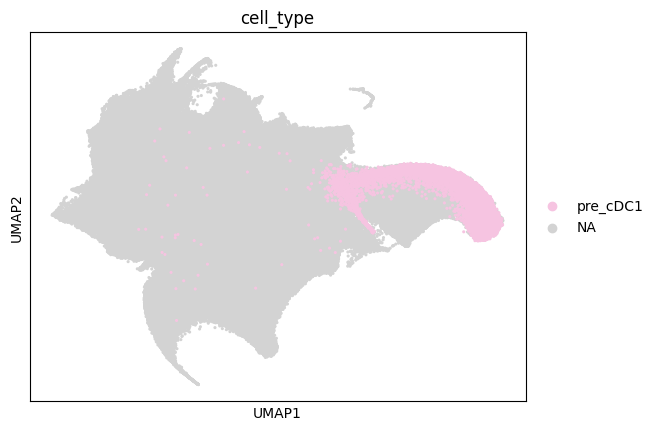

In [76]:
sc.pl.umap(adata, color="cell_type", s=20, groups="pre_cDC1")

In [65]:
rename_map = {
    "late_MgkPro": "MgkPro",
    "pre_cDC1": "Pre-DC1",
    "pre_cDC2": "Pre-DC2",
}

color_map = {
    'HSCs': '#003049',
    'earlyMPP': '#023e8a',
    'MPP': '#005f73',
    'GMP-Neutro': '#0a9396',
    'GMP_cycling': '#1d3557',
    'MPP_MgkEry': '#264653',
    'MgKEryPro1': '#7f908f',
    'MgKEryPro2': '#4a5c6a',
    'MgkPro': '#3a4f6a',
    'EosBasMast1': '#6c757d',
    'EosBasMast2': '#780000',
    'EosBasMast3': '#9d0910',
    'EryPro': '#af0e18',
    'MLP': '#c1121f',
    'LMPP-CLP': '#ae2012',
    'preProB': '#9b2226',
    'ProB': '#df817a',
    'Pre-DC1': '#e76f51',
    'Pre-DC2': '#f4a261',
    'Early_GMP': '#ee9b00',
    'CD14Mono': '#fdf0d5',
    'CD16Mono': '#e9d8a6',
    'CyclingPro1': '#669bbc',
    'CyclingPro2': '#8ecae6',
}

In [61]:
exp_number_ct_prop = {}
adata = adata[~adata.obs.cell_type.isna()]

for exp_no in np.unique(adata.obs.experiment_number):
    adata_exp = adata[adata.obs.experiment_number==exp_no]
    ct_prop = adata_exp.obs.cell_type.value_counts()
    for ct in np.unique(adata.obs.cell_type):
        if ct not in ct_prop.index:
            ct_prop[ct] = 0
    exp_number_ct_prop[exp_no] = ct_prop

In [71]:
map_prot_to_ct = dict(zip(unique_protocols.index, unique_protocols.enriched_ct))

for exp_no in exp_number_ct_prop:
    
    data = exp_number_ct_prop[exp_no]
    # convert to proportions
    prop = data / data.sum()
    
    # Rename cell types
    prop.index = prop.index.map(lambda x: rename_map.get(x, x))
    
    # Keep only top 12 cell types by proportion
    prop = prop.nlargest(12)
    
    # Map colors to the cell types present in this experiment
    colors = [color_map.get(ct, '#cccccc') for ct in prop.index]
    
    fig, ax = plt.subplots(figsize=(5,3))
    sns.barplot(x=prop.index, y=prop.values, palette=colors, ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.set_ylabel("Proportion")
    ax.set_title(f"Experiment {exp_no} / exp type {map_prot_to_ct[float(exp_no)]}")
    plt.tight_layout()
    
    plt.show()
    # plt.close(fig)

NameError: name 'unique_protocols' is not defined